# `TM_CCOEFF` candidate-score distributions, one ROI per domain

**Purpose.** `Research Logs/2026-09-01-tm-variant-sweep.md` found `TM_CCOEFF` (unnormalised,
on the `hematoxylin_od` channel) the best candidate generator of the six `cv2.TM_*` methods
tested -- see its section 5 headline table. The production floor for filtering the raw peak
list before NMS is `median + 0.5 * MAD` of the response map's own robust statistics
(`template_match.robust_stats`, `FLOOR_Z = 0.5` in `tm_variant_sweep.py`).

This notebook makes that floor visible. For each of the 7 tumour domains it:

1. picks the domain's densest downloaded ROI (`experiment.select_domain_images`),
2. seeds one `TM_CCOEFF` search the same way `tm_variant_sweep.draw_seeds` draws seed
   index 0 (pathologist-agreement pool, border-filtered, `default_rng([0, image_id])`),
3. matches the full ROI with a single 51x51 template (no rotation/scale augmentation --
   matches the config the sweep's headline `TM_CCOEFF` numbers were measured with),
4. extracts **every** local-maximum peak (`template_match.extract_peaks`) at an
   unfiltered floor -- this is the full "post-TM, pre-NMS" candidate population the
   `score_threshold` argument actually filters,
5. plots that population's histogram per domain, with the current
   `median + 0.5*MAD` floor marked.

**Why raw scores aren't compared across domains.** `TM_CCOEFF` is unnormalised, so its
magnitude scales with the template's own pixel variance -- a property of *that click*, not
of the domain. That is exactly why the floor is computed per-map, in that map's own robust
z-units, rather than as one fixed cutoff. The panels below make this concrete: each
domain's distribution sits at a different absolute location and spread, but the floor
formula tracks it in every panel.

In [1]:
import time
NB_T0 = time.time()

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from midog_utils import dataset as ds
from midog_utils import channels as ch
from midog_utils import experiment as ex
from midog_utils import find_and_suppress as fs
from midog_utils import seed_selection as ss
from midog_utils import template_match as tm

pd.set_option('display.width', 160)
pd.set_option('display.max_columns', 30)
print('imports ok')

imports ok


## Configuration

Held fixed at the sweep's headline `TM_CCOEFF` arm: `hematoxylin_od` channel, single
51 px template, no rotation/flip augmentation, `peak_min_distance = 7` (the same local-max
spacing `find_and_suppress` uses at extraction). `SEED_INDEX = 0` reproduces the first of
the sweep's 5 independent seed streams, so this notebook's peak population is directly
comparable to a row of `results/tm_variant_sweep.csv` were it re-run today.

`FLOOR_Z = 0.5` is the threshold multiplier this notebook is auditing -- change it here to
see the line move.

In [2]:
CHANNEL = 'hematoxylin_od'
METHOD = cv2.TM_CCOEFF
BASE_SIZE = tm.BASE_SIZE          # 51 px
PEAK_MIN_DISTANCE = 7
FLOOR_Z = 0.5                     # the current median + 0.5*MAD formula
SEED_INDEX = 0                    # tm_variant_sweep's first of 5 seed streams
MAX_PEAKS = 2_000_000             # far above any ROI's local-max count; extraction is unfiltered

CFG = fs.FSConfig(channel=CHANNEL, base_size=BASE_SIZE, scales=(1.0,),
                  n_angles=1, flips=(False,), peak_min_distance=PEAK_MIN_DISTANCE)
BORDER = CFG.patch_size // 2

## One ROI per domain

The same rule `experiment.select_domain_images` and the sweep both use: the downloaded
image with the most mitotic figures in each domain. 001.tiff (zero mitotic figures) is
excluded automatically.

In [3]:
images, annotations = ds.load_annotations()
ds.check_invariants(annotations)
domain_images = ex.select_domain_images(images, annotations, images_dir='images')
domain_images = domain_images.sort_values('tumor_type').reset_index(drop=True)
domain_images[['tumor_type', 'file_name', 'image_id', 'n_mitotic']]

,tumor_type,file_name,image_id,n_mitotic
0,canine cutaneous mast cell tumor,301.tiff,301,218
1,canine lung cancer,201.tiff,201,18
2,canine lymphosarcoma,246.tiff,246,116
3,canine soft tissue sarcoma,459.tiff,459,131
4,human breast cancer,094.tiff,94,82
5,human melanoma,548.tiff,548,239
6,human neuroendocrine tumor,402.tiff,402,105


## Match, extract, measure -- one domain at a time

Each ROI is ~2 mm^2 (4800-6600 px a side); loaded, matched and its full peak population
extracted, then the RGB/channel arrays are dropped before moving to the next domain so
memory stays bounded on this CPU-only machine.

`extract_peaks` is called with `score_threshold=-inf`, so `n_peaks` below is the **entire**
local-maximum population at `peak_min_distance=7` -- nothing has been filtered by score yet.
That population, not the raw response map, is what a `score_threshold` change in
`find_and_suppress` actually keeps or drops.

In [4]:
records = []
peak_scores = {}

for _, row in domain_images.iterrows():
    fn, image_id, domain = row['file_name'], int(row['image_id']), row['tumor_type']
    t0 = time.time()

    rgb = ds.load_roi(f'images/{fn}')
    hem = ch.to_channel(rgb, CHANNEL)
    gt = ds.image_annotations(annotations, fn)
    gt_mit = gt[gt['category_id'] == ds.MITOTIC]

    pool, flagged = ss.agreement_pool(gt_mit)
    pool = ss.border_filter(pool, BORDER, rgb.shape)
    rng = np.random.default_rng([SEED_INDEX, image_id])
    seed = pool.iloc[int(rng.integers(len(pool)))]
    seed_xy = (float(seed['cx']), float(seed['cy']))

    patch = tm.read_padded_patch(hem, *seed_xy, CFG.patch_size)
    templates, _ = tm.build_augmentations(patch, CFG.base_size, CFG.scales,
                                          CFG.n_angles, CFG.flips)

    fused, best, valid = tm.fused_response(hem, templates, CFG.scale_normalize, method=METHOD)
    med, mad = tm.robust_stats(fused, valid)
    floor = med + FLOOR_Z * mad

    centers, scores = tm.extract_peaks(fused, valid, PEAK_MIN_DISTANCE, float('-inf'), MAX_PEAKS)
    kept = scores >= floor

    peak_scores[domain] = scores
    records.append({
        'domain': domain, 'file_name': fn, 'image_id': image_id,
        'seed_ann_id': int(seed['ann_id']), 'seed_agreement_flagged': bool(flagged),
        'n_mitotic': int(len(gt_mit)), 'n_pool': int(len(pool)),
        'n_peaks': int(len(scores)), 'map_median': round(med, 4), 'mad_scale': round(mad, 4),
        'floor': round(floor, 4), 'n_kept': int(kept.sum()),
        'frac_kept': round(float(kept.mean()), 4) if len(scores) else float('nan'),
        't_s': round(time.time() - t0, 1),
    })
    print(f"[{fn}] {domain:34s} n_peaks={len(scores):6d} median={med:+.4f} "
          f"mad={mad:.4f} floor={floor:+.4f} kept={kept.mean():.1%} "
          f"[{time.time() - t0:.1f}s]")

    del rgb, hem, fused, best, valid
    import gc; gc.collect()

summary = pd.DataFrame(records).sort_values('domain').reset_index(drop=True)
print(f'\ntotal {time.time() - NB_T0:.0f}s')
summary

[301.tiff] canine cutaneous mast cell tumor   n_peaks= 31053 median=-0.0176 mad=0.2795 floor=+0.1222 kept=94.3% [9.9s]


[201.tiff] canine lung cancer                 n_peaks= 30724 median=-0.0283 mad=0.6125 floor=+0.2780 kept=86.5% [8.6s]


[246.tiff] canine lymphosarcoma               n_peaks= 42012 median=-0.0057 mad=0.1935 floor=+0.0911 kept=94.4% [6.8s]


[459.tiff] canine soft tissue sarcoma         n_peaks= 20855 median=-0.1598 mad=1.2429 floor=+0.4617 kept=88.6% [6.4s]


[094.tiff] human breast cancer                n_peaks= 36834 median=-0.0108 mad=0.1188 floor=+0.0486 kept=82.6% [10.8s]


[548.tiff] human melanoma                     n_peaks= 22714 median=-0.2213 mad=1.5145 floor=+0.5359 kept=86.9% [14.8s]


[402.tiff] human neuroendocrine tumor         n_peaks= 31104 median=-0.1138 mad=1.9103 floor=+0.8413 kept=91.4% [11.3s]

total 84s


,domain,file_name,image_id,seed_ann_id,seed_agreement_flagged,n_mitotic,n_pool,n_peaks,map_median,mad_scale,floor,n_kept,frac_kept,t_s
0,canine cutaneous mast cell tumor,301.tiff,301,14969,False,218,162,31053,-0.0176,0.2795,0.1222,29277,0.9428,9.9
1,canine lung cancer,201.tiff,201,4457,False,18,7,30724,-0.0283,0.6125,0.2780,26568,0.8647,8.6
2,canine lymphosarcoma,246.tiff,246,6548,False,116,97,42012,-0.0057,0.1935,0.0911,39652,0.9438,6.8
3,canine soft tissue sarcoma,459.tiff,459,22441,False,131,121,20855,-0.1598,1.2429,0.4617,18480,0.8861,6.4
4,human breast cancer,094.tiff,94,2512,False,82,49,36834,-0.0108,0.1188,0.0486,30407,0.8255,10.8
5,human melanoma,548.tiff,548,25804,False,239,184,22714,-0.2213,1.5145,0.5359,19740,0.8691,14.8
6,human neuroendocrine tumor,402.tiff,402,20254,False,105,65,31104,-0.1138,1.9103,0.8413,28422,0.9138,11.3


**Reading `frac_kept`.** `floor = map_median + 0.5*mad_scale` is computed over the
*whole* response map (background included, subsampled every 8th pixel), while the
population being filtered is local-maximum peaks only -- which are already biased toward
the high end of the map's distribution. A peak surviving `min_distance=7` is not a random
map pixel, so `frac_kept` is not close to the ~69% a Gaussian's `z=0.5` cut would keep
(`0.5*MAD` maps to roughly `0.337*sigma` under normality); expect it far higher. That gap
is the actual number to look at when judging "how much would a higher multiple filter out"
-- it is read directly off the histograms below.

## Per-domain score distributions

One panel per domain, sorted by `tumor_type`. Dashed line = `median + 0.5*MAD` (the current
production floor); dotted line = the map's raw median, for scale. Bin range is the observed
peak-score range for that domain, so panels are not on a shared x-axis -- see the note above
on why raw `TM_CCOEFF` magnitude is not comparable across domains.

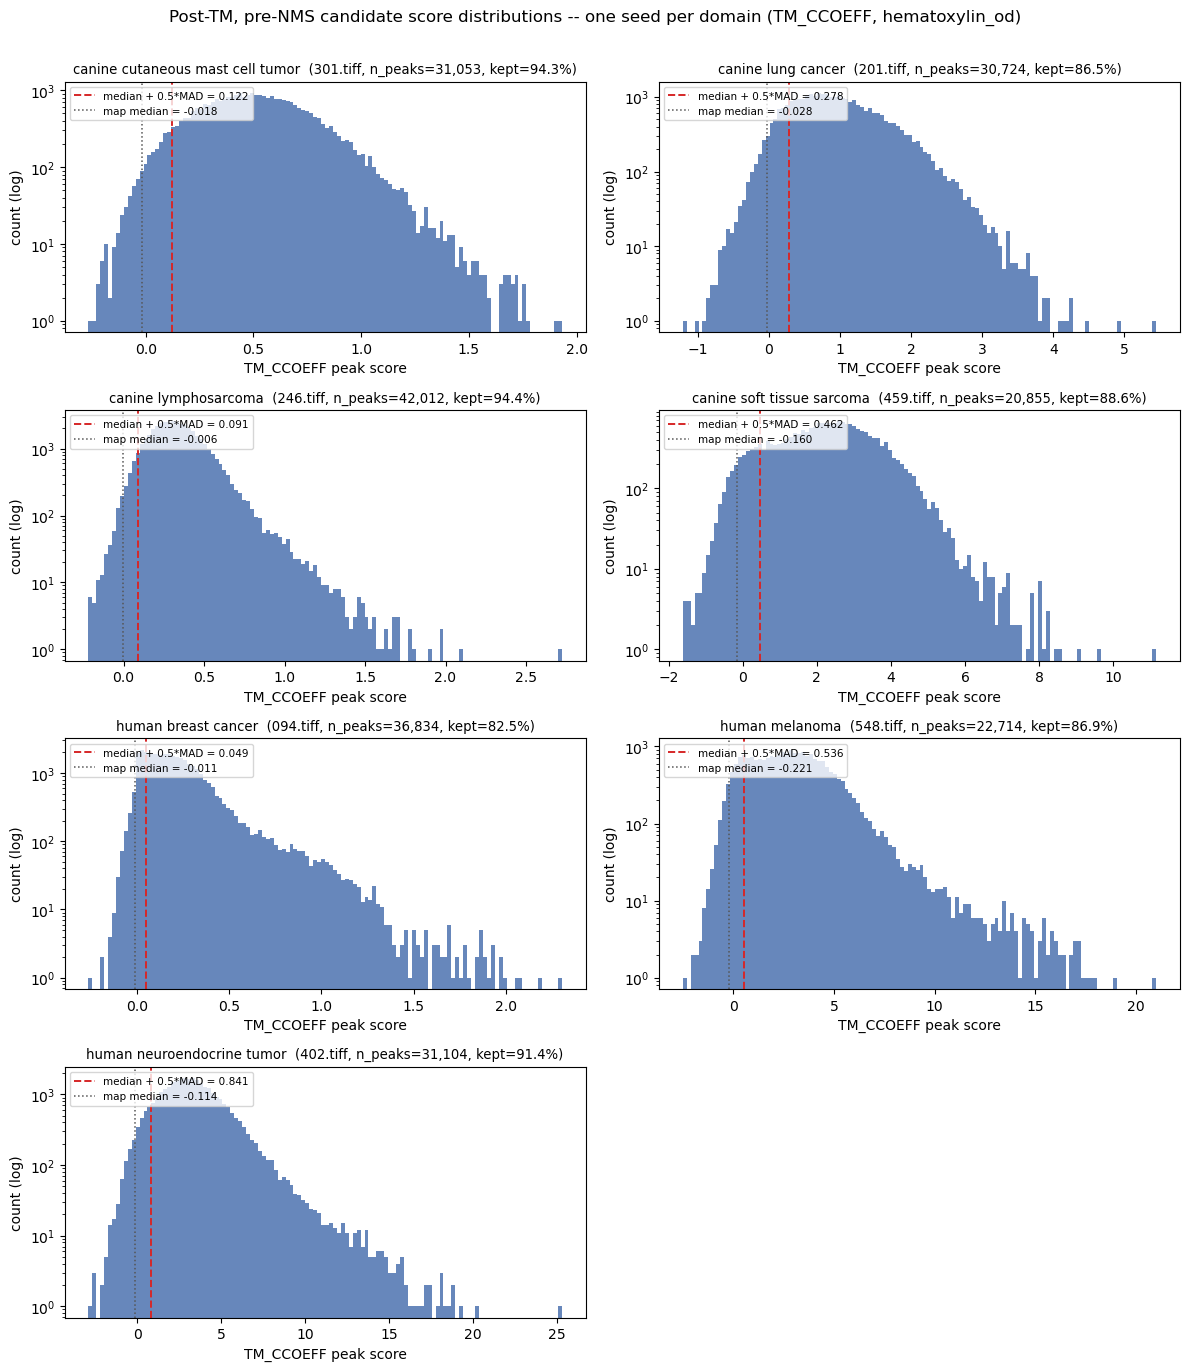

In [5]:
domains = summary['domain'].tolist()
n = len(domains)
ncols = 2
nrows = -(-n // ncols)
fig, axes = plt.subplots(nrows, ncols, figsize=(12, 3.4 * nrows))
axes = np.atleast_1d(axes).ravel()

for ax, domain in zip(axes, domains):
    rec = summary[summary['domain'] == domain].iloc[0]
    scores = peak_scores[domain]
    ax.hist(scores, bins=120, color='#4c72b0', alpha=0.85, log=True)
    ax.axvline(rec['floor'], color='#d62728', linestyle='--', linewidth=1.4,
              label=f"median + 0.5*MAD = {rec['floor']:.3f}")
    ax.axvline(rec['map_median'], color='#555555', linestyle=':', linewidth=1.1,
              label=f"map median = {rec['map_median']:.3f}")
    ax.set_title(f"{domain}  ({rec['file_name']}, n_peaks={rec['n_peaks']:,}, "
                f"kept={rec['frac_kept']:.1%})", fontsize=9.5)
    ax.set_xlabel('TM_CCOEFF peak score')
    ax.set_ylabel('count (log)')
    ax.legend(fontsize=7.5, loc='upper left')

for ax in axes[n:]:
    ax.set_visible(False)

fig.suptitle('Post-TM, pre-NMS candidate score distributions -- one seed per domain '
            '(TM_CCOEFF, hematoxylin_od)', y=1.005, fontsize=12)
fig.tight_layout()
plt.show()

## All domains on one axis

The same distributions as robust z-scores -- `(score - map_median) / mad_scale` -- which
puts every domain on the same scale and makes the current floor a single vertical line at
`z = 0.5` for all seven. Useful for judging whether one multiplier is a reasonable
compromise across domains, or whether some domain's tail is systematically fatter/thinner
than the others at that cut.

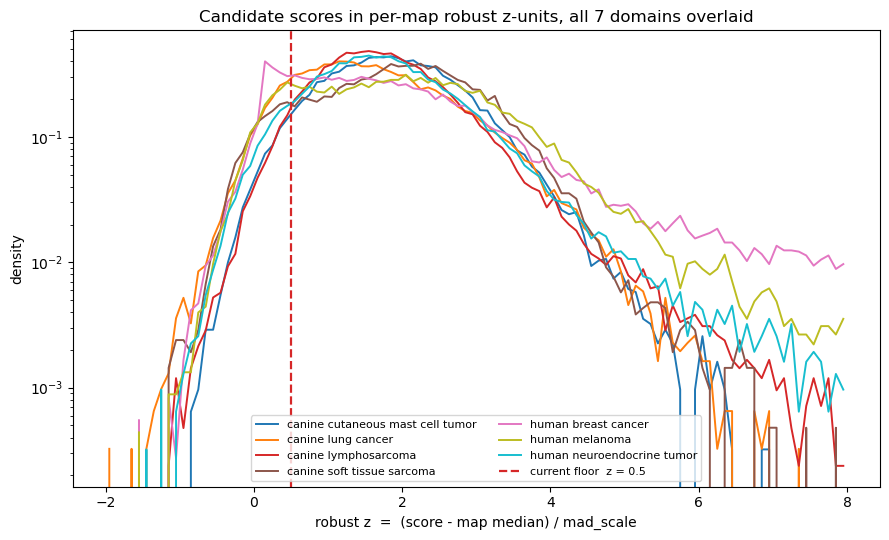

In [6]:
fig, ax = plt.subplots(figsize=(9, 5.5))
colors = plt.cm.tab10(np.linspace(0, 1, n))

for domain, color in zip(domains, colors):
    rec = summary[summary['domain'] == domain].iloc[0]
    z = (peak_scores[domain] - rec['map_median']) / rec['mad_scale']
    counts, edges = np.histogram(z, bins=100, range=(-2, 8), density=True)
    centers_x = 0.5 * (edges[:-1] + edges[1:])
    ax.plot(centers_x, counts, color=color, label=domain, linewidth=1.4)

ax.axvline(FLOOR_Z, color='#d62728', linestyle='--', linewidth=1.6,
          label=f'current floor  z = {FLOOR_Z}')
ax.set_xlabel('robust z  =  (score - map median) / mad_scale')
ax.set_ylabel('density')
ax.set_yscale('log')
ax.set_title('Candidate scores in per-map robust z-units, all 7 domains overlaid')
ax.legend(fontsize=8, ncol=2)
fig.tight_layout()
plt.show()

## Summary table

`frac_kept` at the current `z=0.5` floor, and what a higher multiplier would keep instead
(`z=1.0`, `z=1.5`), computed from the same peak populations above with no re-matching.

In [7]:
rows = []
for domain in domains:
    rec = summary[summary['domain'] == domain].iloc[0]
    scores = peak_scores[domain]
    z = (scores - rec['map_median']) / rec['mad_scale'] if rec['mad_scale'] > 0 else np.full_like(scores, np.nan)
    rows.append({
        'domain': domain, 'file_name': rec['file_name'], 'n_peaks': rec['n_peaks'],
        'kept @ z=0.5 (current)': round(float((z >= 0.5).mean()), 4),
        'kept @ z=1.0': round(float((z >= 1.0).mean()), 4),
        'kept @ z=1.5': round(float((z >= 1.5).mean()), 4),
        'kept @ z=2.0': round(float((z >= 2.0).mean()), 4),
    })
kept_table = pd.DataFrame(rows)
kept_table

,domain,file_name,n_peaks,kept @ z=0.5 (current),kept @ z=1.0,kept @ z=1.5,kept @ z=2.0
0,canine cutaneous mast cell tumor,301.tiff,31053,0.9428,0.8302,0.6521,0.4369
1,canine lung cancer,201.tiff,30724,0.8647,0.6954,0.5021,0.3299
2,canine lymphosarcoma,246.tiff,42012,0.9439,0.8090,0.5878,0.3575
3,canine soft tissue sarcoma,459.tiff,20855,0.8861,0.7882,0.6615,0.4915
4,human breast cancer,094.tiff,36834,0.8255,0.6802,0.5383,0.4030
5,human melanoma,548.tiff,22714,0.8691,0.7491,0.6273,0.4912
6,human neuroendocrine tumor,402.tiff,31104,0.9138,0.7856,0.5887,0.3746


**Reading this table.** Each column is a candidate multiple for `FLOOR_Z`; moving from
0.5 to 1.5 or 2.0 shows directly, per domain, how much of the post-TM candidate pool a
stricter floor would remove before NMS ever runs -- without re-running the match. This
notebook does not decide the value; it makes the tradeoff visible per domain so the choice
can be made against genuine recall (e.g. `results/tm_variant_sweep.csv`,
`Research Logs/2026-09-01-tm-variant-sweep.md`), not just candidate-count reduction.